In [5]:
!pip install pyspark --quiet

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings

from pyspark.sql import SparkSession

warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName('Day4_BigData_Sales') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()

print(f'Spark version : {spark.version}')
print(f'SparkSession  : ACTIVE')
print(f'Application   : {spark.sparkContext.appName}')

Spark version : 4.0.2
SparkSession  : ACTIVE
Application   : Day4_BigData_Sales


In [8]:
df_bronze = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("large_sales_data.csv")

print("=== BRONZE LAYER - Raw Data ===")
print(f"Rows: {df_bronze.count()}")
print(f"Columns: {len(df_bronze.columns)}")
print(f"Names: {df_bronze.columns}")
print()

df_bronze.printSchema()

=== BRONZE LAYER - Raw Data ===
Rows: 5000
Columns: 13
Names: ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [9]:
print('First 5 rows:')
df_bronze.show(5, truncate=False)
print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [10]:
df_bronze.write \
    .mode("overwrite") \
    .parquet("sales_bronze.parquet")
print("Bronze parquet saved: sales_bronze.parquet")
import os

Bronze parquet saved: sales_bronze.parquet


In [11]:
from pyspark.sql.functions import col, to_date

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=["order_id", "product", "revenue"])

df_silver = df_silver.withColumn(
    "order_date",
    to_date(col("order_date"), "yyyy-MM-dd")
)

df_silver.show()

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+------------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|   sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+------------+----------------+------------+
|    1246|  Divya Singh|  Keyboard|Accessories|      11|      1200|  13200|2023-02-07|  Kolkata|  East| Kavya Reddy|     Net Banking|     Shipped|
|    1323|   Ananya Das|    Webcam|Accessories|       7|      2500|  17500|2023-01-24|  Kolkata|  East| Meera Patel|             UPI|   Delivered|
|    1386|Kavya Nambiar|   Speaker|Electronics|      13|      4500|  58500|2023-04-16|Bangalore| South| Meera Patel|     Credit Card|  Processing|
|    1939|   Amit Verma|  Keyboard|Accessories|       8|      1200|   9600|2023-12-21|  Kolkata|  East|  Priya Nair|  

In [12]:
from pyspark.sql import functions as F
from pyspark.sql.functions import to_date

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id', 'product', 'revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date('order_date', 'dd-MM-yyyy')
)

df_silver = df_silver \
    .withColumn('order_year', F.year(F.col('order_date'))) \
    .withColumn('order_month', F.month(F.col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(F.col('revenue') > 40000, 'High')
     .when(F.col('revenue') > 10000, 'Medium')
     .otherwise('Low')
)

print(f'Silver layer rows : {df_silver.count()}')
print('New columns added: order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','revenue_category').show(8)


Silver layer rows : 5000
New columns added: order_year, order_month, revenue_category
+----------+-------+----------+----------------+
|   product|revenue|order_year|revenue_category|
+----------+-------+----------+----------------+
|  Keyboard|  13200|      2023|          Medium|
|    Webcam|  17500|      2023|          Medium|
|   Speaker|  58500|      2023|            High|
|  Keyboard|   9600|      2023|             Low|
|    Laptop| 180000|      2023|            High|
|Headphones|  38500|      2023|          Medium|
|    Webcam|  35000|      2023|          Medium|
|    Laptop| 360000|      2023|            High|
+----------+-------+----------+----------------+
only showing top 8 rows


In [13]:
import os

def get_dir_size(path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for file in filenames:
            fp = os.path.join(dirpath, file)
            total_size += os.path.getsize(fp)
    return total_size / 1024  # Size in KB

In [14]:
df_silver.write \
    .mode('overwrite') \
    .parquet('sales_silver.parquet')

print('Silver Parquet saved: sales_silver.parquet')

print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')

df_verify = spark.read.parquet('sales_silver.parquet')

print(f'Read-back rows: {df_verify.count()} (should match Silver count)')

df_verify.printSchema()
df_verify.show(5)

Silver Parquet saved: sales_silver.parquet
Silver size: 59.8 KB
Read-back rows: 5000 (should match Silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)

+--------+-------------+--------+-----------+--------+----------+-------+----------+---------+------+-----------+--------------+------------+----------+-----------+----------------+
|order_id|customer_name| produ

In [15]:
top_products = df_silver \
    .groupBy('product') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.avg('revenue').alias('avg_order_revenue')
    )\
    .orderBy('total_revenue',ascending=False) \
    .limit(5)
print("=== Top 5 Products by Revenue ===")
top_products.show(truncate = False)

=== Top 5 Products by Revenue ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [16]:
from pyspark.sql import functions as F
from pyspark.sql.functions import round as spark_round

# Gold Layer 1 - Region Revenue Summary
region_revenue = df_silver \
    .groupBy("region") \
    .agg(
        F.sum("revenue").alias("total_revenue"),
        F.count("order_id").alias("total_orders")
    ) \
    .orderBy("total_revenue", ascending=False)

region_revenue.write \
    .mode("overwrite") \
    .parquet("sales_gold_region.parquet")

print("Gold 1 saved: sales_gold_region.parquet")

# Gold Layer 2 - Product Summary
gold_products = df_silver \
    .groupBy("product") \
    .agg(
        F.sum("revenue").alias("total_revenue"),
        F.count("order_id").alias("num_orders"),
        spark_round(F.avg("quantity"), 2).alias("avg_quantity_per_order"),
        F.max("revenue").alias("largest_order")
    ) \
    .orderBy("total_revenue", ascending=False)

gold_products.write \
    .mode("overwrite") \
    .parquet("gold_product_summary.parquet")

print("Gold 2 saved: gold_product_summary.parquet")

Gold 1 saved: sales_gold_region.parquet
Gold 2 saved: gold_product_summary.parquet


In [17]:
from pyspark.sql import functions as F
from pyspark.sql.functions import round as spark_round

# Gold Layer 1 - Region Revenue
region_revenue = df_silver \
    .groupBy('region') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('total_orders')
    ) \
    .orderBy('total_revenue', ascending=False)

gold_region = region_revenue

gold_region.write \
    .mode('overwrite') \
    .parquet('gold_region_revenue.parquet')

print('Gold 1 saved: gold_region_revenue.parquet')


# Gold Layer 2 - Product Revenue
gold_products = df_silver \
    .groupBy('product', 'category') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('units_sold'),
        spark_round(F.avg('quantity'), 1).alias('avg_quantity_per_order'),
        F.max('revenue').alias('largest_order')
    ) \
    .orderBy('total_revenue', ascending=False)

gold_products.write \
    .mode('overwrite') \
    .parquet('gold_product_revenue.parquet')

print('Gold 2 saved: gold_product_revenue.parquet')


# Gold Layer 3 - Monthly Revenue Trend
monthly_trend = df_silver \
    .groupBy('order_year', 'order_month') \
    .agg(
        F.sum('revenue').alias('monthly_revenue'),
        F.count('order_id').alias('total_orders')
    ) \
    .orderBy('order_year', 'order_month')

gold_monthly = monthly_trend

gold_monthly.write \
    .mode('overwrite') \
    .parquet('gold_monthly_revenue.parquet')

print('Gold 3 saved: gold_monthly_revenue.parquet')


print('\nMedallion Pipeline Complete')
print('Bronze -> sales_bronze.parquet (raw data)')
print('Silver -> sales_silver.parquet (cleaned & enriched)')
print('Gold 1 -> gold_region_revenue.parquet')
print('Gold 2 -> gold_product_revenue.parquet')
print('Gold 3 -> gold_monthly_revenue.parquet')

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_product_revenue.parquet
Gold 3 saved: gold_monthly_revenue.parquet

Medallion Pipeline Complete
Bronze -> sales_bronze.parquet (raw data)
Silver -> sales_silver.parquet (cleaned & enriched)
Gold 1 -> gold_region_revenue.parquet
Gold 2 -> gold_product_revenue.parquet
Gold 3 -> gold_monthly_revenue.parquet


In [18]:
region_pd = spark.read.parquet('gold_region_revenue.parquet').toPandas()

product_pd = spark.read.parquet('gold_product_revenue.parquet').toPandas()

monthly_pd = spark.read.parquet('gold_monthly_revenue.parquet').toPandas()

print('Gold tables converted to Pandas:')
print(f'Region  : {region_pd.shape}')
print(f'Product : {product_pd.shape}')
print(f'Monthly : {monthly_pd.shape}')
region_pd = region_pd.sort_values('total_revenue',ascending=False)
product_pd = product_pd.sort_values('total_revenue',ascending=False)
monthly_pd = monthly_pd.sort_values('order_month')

Gold tables converted to Pandas:
Region  : (4, 3)
Product : (10, 6)
Monthly : (12, 4)


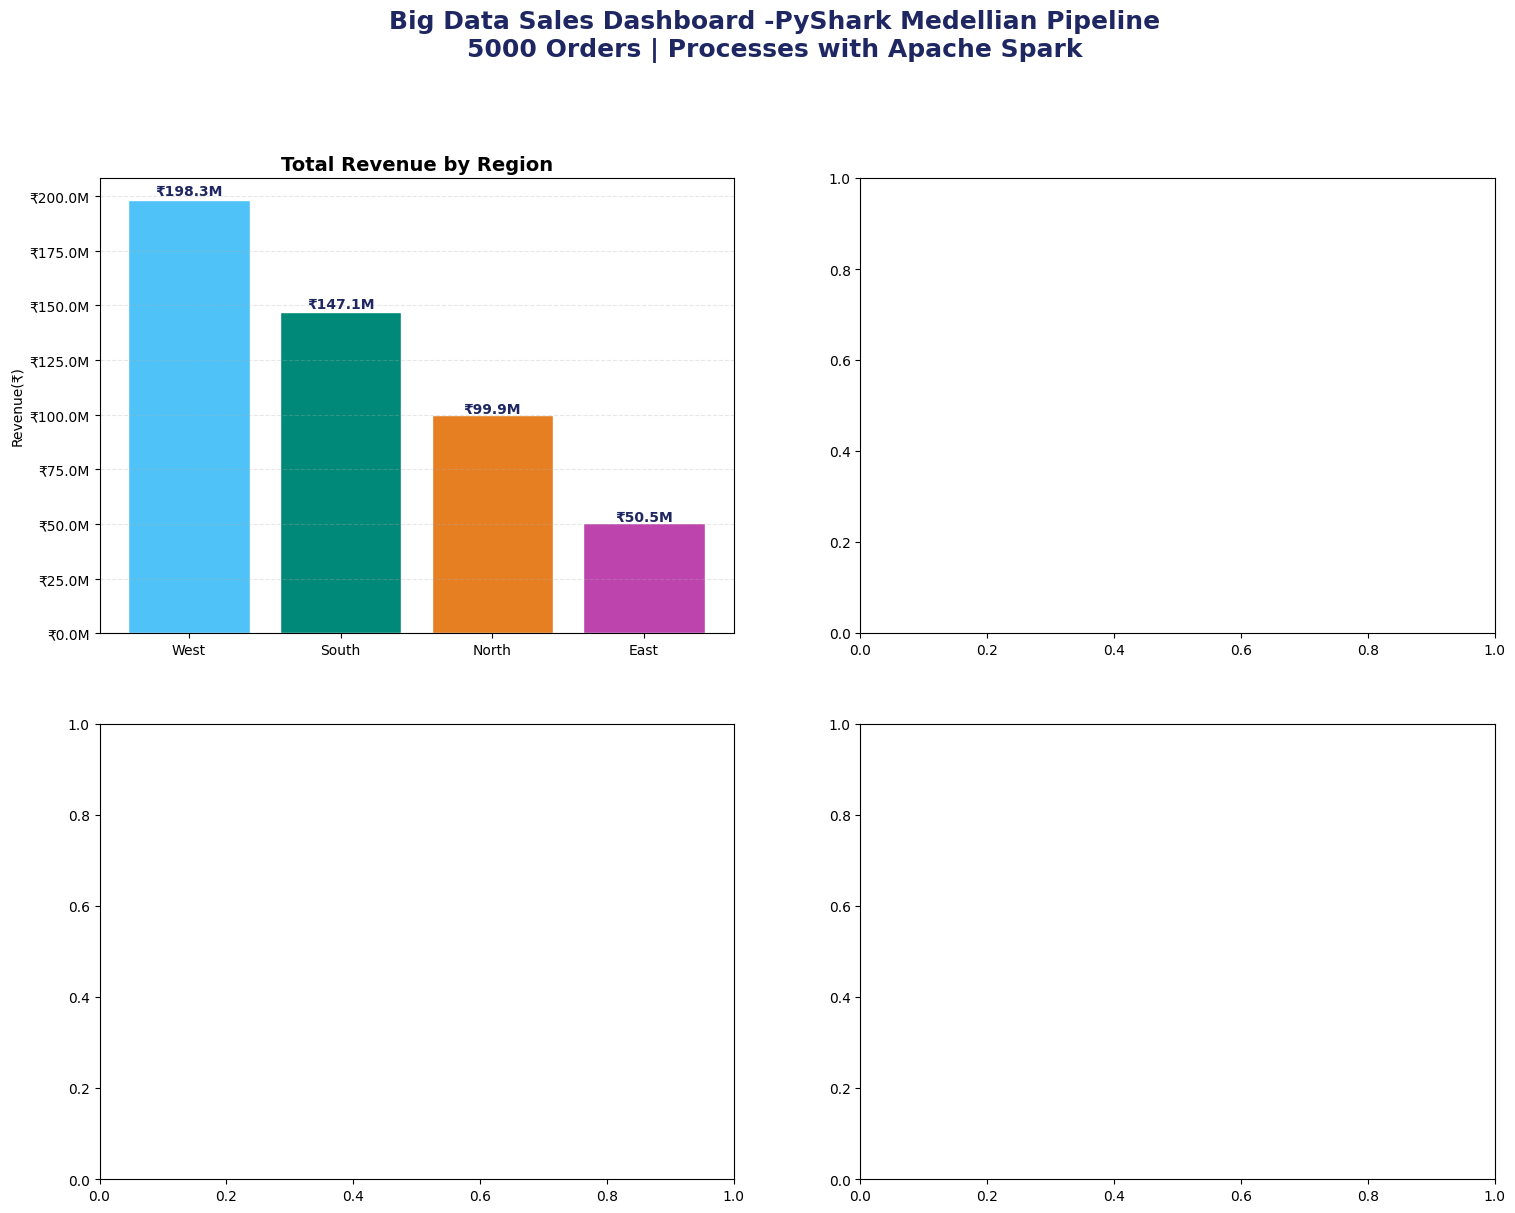

In [19]:
fig, axes = plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
     'Big Data Sales Dashboard -PyShark Medellian Pipeline\n'
     '5000 Orders | Processes with Apache Spark',
     fontsize=18,fontweight='bold',color='#1E2761',y=1.01

)
colors=['#4FC3F7','#008978','#E67E22','#BE44AD','#E74C3C']
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],
              color=colors[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
           ha='center',fontsize=10,fontweight='bold',color='#1E2761')

ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue(₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'₹{x/1e6:.1f}M'))
ax1.grid(axis='y',alpha=0.3,linestyle='--')